# COCO YOLO Convolutional Neural Network (Keras)

Microsoft Common Objects in Context (MS COCO) is a large-scale benchmark dataset designed to advance object detection, instance segmentation, and image captioning research by focusing on objects in their natural, non-iconic context. Unlike prior datasets that emphasise centered, isolated objects, COCO deliberately collects non-iconic images — scenes where objects appear partially occluded, at varied scales, and amid real-world clutter — making it significantly more challenging than PASCAL VOC or ImageNet. The dataset contains over 330,000 images (more than 200,000 labeled), 1.5 million object instances, 80 object ("thing") categories, 91 stuff categories, and an average of 7.7 instances per image. Annotations were gathered using a three-stage Amazon Mechanical Turk pipeline: category labeling, instance spotting, and pixel-level instance segmentation — totalling over 70,000 worker hours. Each image is annotated with precise bounding boxes and segmentation masks, enabling both detection and localisation tasks. COCO was introduced by Lin et al. (Microsoft Research, 2015) and has since become the standard benchmark for modern object detection architectures including YOLO.

**Architecture:**
`416×416×3 input → Conv(64, 3×3) + BN + ReLU → MaxPool(2×2) → Conv(128, 3×3) + BN + ReLU → MaxPool(2×2) → Conv(256, 3×3) + BN + ReLU → MaxPool(2×2) → Conv(256, 3×3) + BN + ReLU + Dropout(0.3) → MaxPool(2×2) → Conv(512, 3×3) + BN + ReLU + Dropout(0.3) → MaxPool(2×2) → Conv(170, 1×1, sigmoid) → 13×13×170 output`

**Techniques:**
TensorFlow/Keras fully convolutional architecture · YOLO grid-based object detection (S=13, B=2, C=80) · YOLO loss with 5 weighted components (coord, size, objectness, no-object, class) · Batch Normalisation after every Conv layer · Dropout(0.3) regularisation · 1×1 detection head preserving spatial structure · Adam optimiser (lr=0.0001) · EarlyStopping (patience=15) to prevent overfitting

**Outputs:**
`13×13×170` tensor — a 13×13 grid where each cell predicts 2 bounding boxes. Each box is encoded as 85 values: `[objectness, x, y, w, h, class×80]`. The full output covers all 80 COCO object categories.

**Result:**
| Metric | Loss |
|--------|------|
| Final training | 0.0369 |
| Final validation | 0.0606 |
| Test | 0.0535 |
| Epochs run | 24 of 300 |

---
## Installing Dependencies

In [1]:
%pip install tensorflow tensorflow-datasets -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Imports: Dataset ───────────────────────────────────────────────────────────────

# TensorFlow Datasets
import tensorflow_datasets as tfds
#tfds.list_builders() # See all tensorflow datasets

dataset, dataset_info = tfds.load('coco/2017', with_info=True)
print(dataset_info)

tfds.core.DatasetInfo(
    name='coco',
    full_name='coco/2017/1.1.0',
    description="""
    COCO is a large-scale object detection, segmentation, and
    captioning dataset.
    
    Note:
     * Some images from the train and validation sets don't have annotations.
     * Coco 2014 and 2017 uses the same images, but different train/val/test splits
     * The test split don't have any annotations (only images).
     * Coco defines 91 classes but the data only uses 80 classes.
     * Panotptic annotations defines defines 200 classes but only uses 133.
    """,
    config_description="""
    
    This version contains images, bounding boxes and labels for the 2017 version.
    
    """,
    homepage='http://cocodataset.org/#home',
    data_dir='/Users/joehill/tensorflow_datasets/coco/2017/1.1.0',
    file_format=tfrecord,
    download_size=25.20 GiB,
    dataset_size=24.98 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/fil

In [3]:
# TensorFlow / Keras — the deep-learning framework
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Numerical + plotting helpers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

---
## Viewing Our Data

Using `print(dataset_info)` we get the list of features and information stored about each image. The output is:

 ```python
  splits={                                                                                                                                                                 
      'test':       <SplitInfo num_examples=40670,  num_shards=64>,                                                                                                        
      'train':      <SplitInfo num_examples=118287, num_shards=256>,                                                                                                       
      'validation': <SplitInfo num_examples=5000,   num_shards=8>,
  }                                                                                                                                                                        
  ```             
                                                                                                                                                                           
  The dataset is divided into **three splits**:

  | Split | Examples | Shards | Purpose |
  |---|---:|---:|---|
  | **Train** | 118,287 | 256 | Used to fit the model's weights. |
  | **Validation** | 5,000 | 8 | Used during training to monitor generalisation and tune hyperparameters. |                                                                
  | **Test** | 40,670 | 64 | Held out for final evaluation. *Note: COCO's test split has no public annotations.* |
  | **Total** | **163,957** | 328 | |


```python
features=FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'image/id': int64,
    'objects': Sequence({
        'area': int64,
        'bbox': BBoxFeature(shape=(4,), dtype=float32),
        'id': int64,
        'is_crowd': bool,
        'label': ClassLabel(shape=(), dtype=int64, num_classes=80),
    }),
})
```

This is the **schema** of one example — what fields each record has, and what type/shape each field is. Think of it as the "row structure" of a database table. Each example is a dict with 4 top-level keys: `image`, `image/filename`, `image/id`, and `objects`.

### Image Fields

Data about each image itself.

| Field | Type | Meaning |
|---|---|---|
| `image` | `Image(shape=(None, None, 3), dtype=uint8)` | The actual pixel data. `(None, None, 3)` means **variable height × variable width × 3 colour channels** (RGB). `uint8` = pixel values 0–255. The `None`s are why every image can be a different size. |
| `image/filename` | `Text` (string) | The original filename, e.g. `"000000123456.jpg"`. |
| `image/id` | `int64` | Unique numeric ID for the image (matches the official COCO IDs). |

### Objects: a `Sequence` (variable-length list)

This is the important part. **`Sequence` means each image has a *variable number* of objects** — one image might have 1 object, another might have 15. For each object in the image you get:

| Field | Type | Meaning |
|---|---|---|
| `area` | `int64` | The area of the object in pixels² (useful for distinguishing small vs large objects in evaluation). |
| `bbox` | `BBoxFeature(shape=(4,), float32)` | The bounding box: 4 floats `[ymin, xmin, ymax, xmax]`, normalised 0–1. This is what you draw on the image. |
| `id` | `int64` | Unique ID for *this specific annotation* (not the class — every annotation across the whole dataset has a unique id). |
| `is_crowd` | `bool` | `True` if the box covers a *crowd* of objects (e.g. a pile of apples annotated as one box) rather than a single instance. Usually filtered out during training. |
| `label` | `ClassLabel(num_classes=80)` | The class index (0–79). Maps to one of the 80 COCO categories like `person`, `car`, `dog`. The string name comes from `dataset_info.features['objects']['label'].names`. |

### How `Sequence` actually appears in the tensor

Because objects are variable-length, when you grab one example, the per-object fields become **arrays of length N** (where N = number of objects in that image):

- `bbox` → shape `(N, 4)`
- `label` → shape `(N,)`
- `area`, `id`, `is_crowd` → shape `(N,)`



image shape: (480, 640, 3)   ← (H, W, 3)
num objects: 1
bboxes shape: (1, 4)   ← (N, 4) in [ymin, xmin, ymax, xmax]

Ground-truth YOLO targets per object:
 #  objectness  class            one-hot (len 80)             x       y       w       h
 0         1.0  truck            [0,...,1@7,...,0]        0.500   0.537   0.918   0.480


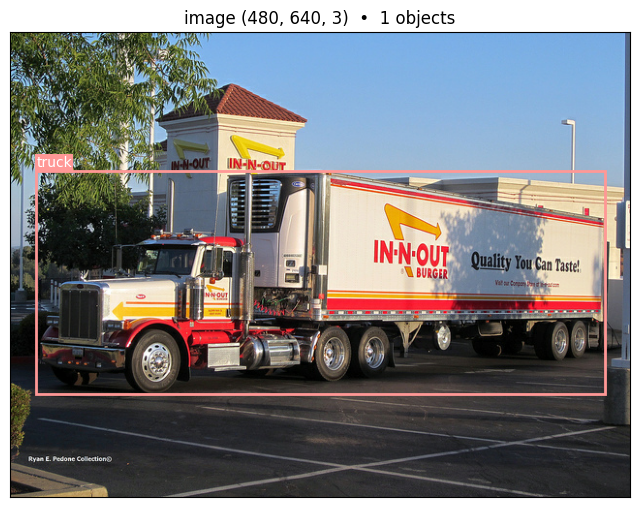

In [4]:
# ── Single-example Inspector ──────────────────────────────────

def show_random_example(ds, shuffle_buffer=2000, seed=None):
    """Pick a random example from `ds`, print its YOLO-style ground truth, and plot it.

    YOLO target per object: [objectness, class one-hot (80), x_center, y_center, w, h]
    All coordinates are normalised to [0, 1] of the image.
    """
    sample = ds.shuffle(shuffle_buffer, seed=seed).take(1)
    example = next(iter(sample))

    image  = example['image'].numpy()
    bboxes = example['objects']['bbox'].numpy()   # [ymin, xmin, ymax, xmax], normalised
    labels = example['objects']['label'].numpy()
    h, w = image.shape[:2]

    print("\nimage shape:", image.shape, "  ← (H, W, 3)")
    print("num objects:", labels.shape[0])
    print("bboxes shape:", bboxes.shape, "  ← (N, 4) in [ymin, xmin, ymax, xmax]")

    print("\nGround-truth YOLO targets per object:")
    print(f"{'#':>2}  {'objectness':>10}  {'class':<16} {'one-hot (len 80)':<22}"
          f"  {'x':>6}  {'y':>6}  {'w':>6}  {'h':>6}")
    for i, (bbox, label) in enumerate(zip(bboxes, labels)):
        ymin, xmin, ymax, xmax = bbox
        x_c = (xmin + xmax) / 2
        y_c = (ymin + ymax) / 2
        bw  = xmax - xmin
        bh  = ymax - ymin

        one_hot = np.zeros(len(class_names), dtype=np.int8)
        one_hot[int(label)] = 1
        one_hot_str = f"[0,...,1@{int(label)},...,0]"

        print(f"{i:>2}  {1.0:>10.1f}  {class_names[int(label)]:<16} {one_hot_str:<22}"
              f"  {x_c:>6.3f}  {y_c:>6.3f}  {bw:>6.3f}  {bh:>6.3f}")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    ax.set_title(f"image {image.shape}  •  {labels.shape[0]} objects")
    ax.set_xticks([]); ax.set_yticks([])

    cmap = plt.get_cmap('tab20')
    for bbox, label in zip(bboxes, labels):
        ymin, xmin, ymax, xmax = bbox
        x, y = xmin * w, ymin * h
        box_w, box_h = (xmax - xmin) * w, (ymax - ymin) * h
        color = cmap(int(label) % 20)
        ax.add_patch(patches.Rectangle((x, y), box_w, box_h,
                                       linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(x, max(y - 4, 0), class_names[int(label)],
                color='white', fontsize=10,
                bbox=dict(facecolor=color, edgecolor='none', pad=1))

    plt.show()

class_names = dataset_info.features['objects']['label'].names
show_random_example(dataset['train'])


## Building Our Model

---
### Hyperparameters

Before building the model we fix the key values that control its structure and training. Images are resized to **416×416** (a standard YOLO input size, divisible by 32 to work cleanly with the convolutional backbone). The image is divided into an **S×S = 7×7 grid** of cells, each predicting **B=2 bounding boxes**. Each box carries 85 values — `objectness + x + y + w + h + 80 class scores` — giving a total output tensor of shape `(7, 7, 170)`.

| Parameter | Meaning |
|---|---|
| `S` | Grid size — image split into S×S cells |
| `box_per_cell` | Bounding box predictions per cell |
| `num_classes` | COCO object categories |
| `input_size` | Fixed input shape fed to the model |
| `output_size` | `S × S × box_per_cell × 85` — flattened prediction tensor |
| `hidden_size` | Neurons in each fully-connected layer |
| `epochs` | Maximum training epochs (early stopping may cut this short) |


In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────

epochs      = 300   # max epochs
S = 13
s_size = (S,S) # SxS grid size for cells
box_per_cell = 2
num_classes = dataset_info.features['objects']['label'].num_classes

training_image_height = training_image_width = 416 # force images to size
test_image_height = test_image_width = 416 # force images to size


input_size  = (training_image_height, training_image_width, 3)  # (x,y, 3)
hidden_size = 128   # neurons in each fully-connected hidden layer
output_size = S * S * box_per_cell * (5 + num_classes)   # one output per digit class (0–9)

---
### Training Settings

Controls how much data is used and how training behaves. We use a **subset of 600 training images and 100 test images** to keep iteration fast while building the model. The full 5,000 validation images are used so evaluation is representative.

**EarlyStopping** monitors `val_loss` and halts training if it hasn't improved for 5 consecutive epochs, restoring the best weights seen — preventing the model from overfitting past its peak.

| Setting | Meaning |
|---|---|
| `num_train` | Training examples used |
| `num_validation` | Full COCO validation split |
| `num_test` | Test examples used |
| `batch_size` | Images processed per gradient update |
| `patience` | Epochs without improvement before stopping |


In [6]:
# Training settings
num_train      = 5000
num_validation = 1000
num_test       = 100
batch_size     = 10

# EarlyStopping callback settings
callbacks = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]


---
### Getting the Data

Here we slice each split from the full COCO dataset using `.take()`. This creates a lazy pipeline — nothing is loaded into memory yet, just the instructions for what to fetch. We also print one example to confirm the image shape and objects structure look correct before processing.

| Variable | Source | Size |
|---|---|---|
| `training_data` | `dataset['train']` | `num_train` examples |
| `validation_data` | `dataset['validation']` | `num_validation` examples |
| `test_data` | `dataset['test']` | `num_test` examples |


In [7]:
# Get Data
training_data   = dataset["train"].take(num_train)

# example image
for example in training_data.take(1):
    print(example['image'].shape)
    print(example['objects'])

validation_data = dataset["validation"].take(num_validation)
test_data       = dataset["validation"].skip(num_validation).take(num_test)  # different images from validation


(462, 640, 3)
{'area': <tf.Tensor: shape=(3,), dtype=int64, numpy=array([17821, 16942,  4344])>, 'bbox': <tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0.54380953, 0.13464062, 0.98651516, 0.33742186],
       [0.50707793, 0.517875  , 0.8044805 , 0.891125  ],
       [0.3264935 , 0.36971876, 0.65203464, 0.4431875 ]], dtype=float32)>, 'id': <tf.Tensor: shape=(3,), dtype=int64, numpy=array([152282, 155195, 185150])>, 'is_crowd': <tf.Tensor: shape=(3,), dtype=bool, numpy=array([False, False, False])>, 'label': <tf.Tensor: shape=(3,), dtype=int64, numpy=array([3, 3, 0])>}


---
### Preparing the Data

Here we convert the raw COCO examples into fixed-shape tensors the model can consume. Two functions handle this:

**`create_output_label`** — converts a single image's variable-length list of objects into a fixed `(S, S, B×85)` YOLO target grid. For each object it finds which grid cell the box centre falls in, then writes `[objectness, x, y, w, h, one-hot class]` into that cell's slot.

**`prepare_split`** — loops over a dataset split, resizes every image to `(416, 416)` and normalises pixels to `[0, 1]`, calls `create_output_label` on the objects, then stacks everything into tensors.

After this cell we have six tensors ready for training:

| Tensor | Shape |
|---|---|
| `training_images` | `(num_train, 416, 416, 3)` |
| `training_labels` | `(num_train, S, S, B×85)` |
| `validation_images` | `(num_validation, 416, 416, 3)` |
| `validation_labels` | `(num_validation, S, S, B×85)` |
| `test_images` | `(num_test, 416, 416, 3)` |
| `test_labels` | `(num_test, S, S, B×85)` |


In [8]:
# Prepare Data

def create_output_label(bboxes, labels, s_size, box_per_cell, num_classes):
    S_rows, S_cols = s_size
    target = np.zeros((S_rows, S_cols, box_per_cell * (5 + num_classes)), dtype=np.float32)
    box_count = np.zeros((S_rows, S_cols), dtype=np.int32)

    for bbox, label in zip(bboxes.numpy(), labels.numpy()):
        ymin, xmin, ymax, xmax = bbox
        x_c = (xmin + xmax) / 2
        y_c = (ymin + ymax) / 2
        w   = xmax - xmin
        h   = ymax - ymin

        col = min(int(x_c * S_cols), S_cols - 1)
        row = min(int(y_c * S_rows), S_rows - 1)

        b = box_count[row, col]
        if b >= box_per_cell:
            continue

        offset = b * (5 + num_classes)
        target[row, col, offset + 0] = 1.0
        target[row, col, offset + 1] = x_c
        target[row, col, offset + 2] = y_c
        target[row, col, offset + 3] = w
        target[row, col, offset + 4] = h
        target[row, col, offset + 5 + int(label)] = 1.0

        box_count[row, col] += 1

    return target


def prepare_split(data, image_h, image_w, s_size, box_per_cell, num_classes):
    images, labels = [], []
    for datapoint in data:
        image = tf.image.resize(datapoint["image"], (image_h, image_w)) / 255.0
        label = create_output_label(
            datapoint['objects']['bbox'],
            datapoint['objects']['label'],
            s_size=s_size,
            box_per_cell=box_per_cell,
            num_classes=num_classes
        )
        images.append(image)
        labels.append(label)
    return tf.stack(images), tf.stack(labels)


# Training
training_images, training_labels = prepare_split(training_data, training_image_height, training_image_width,s_size, box_per_cell, num_classes)

# Validation
validation_images, validation_labels = prepare_split(validation_data, training_image_height, training_image_width,s_size, box_per_cell, num_classes)

# Test
test_images, test_labels = validation_images, validation_labels
#prepare_split(test_data, test_image_height, test_image_width,s_size, box_per_cell, num_classes)

print("training_images:", training_images.shape)
print("training_labels:", training_labels.shape)
print("validation_images:", validation_images.shape)
print("validation_labels:", validation_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)


training_images: (5000, 416, 416, 3)
training_labels: (5000, 13, 13, 170)
validation_images: (1000, 416, 416, 3)
validation_labels: (1000, 13, 13, 170)
test_images: (1000, 416, 416, 3)
test_labels: (1000, 13, 13, 170)


---
### The Network

#### Batch Normalisation
After each `Conv2D` layer we apply `BatchNormalization()` before the activation. This normalises the outputs of each layer so they have a consistent scale during training. Without it, values can grow very large or very small as they pass through deep networks, making training unstable. It also acts as a mild regulariser, helping reduce overfitting.

```
Conv2D → BatchNormalization → Activation("relu")
```

#### Dropout in Convolutional Layers
`Dropout(0.3)` randomly zeroes 30% of the activations during each training step. This forces the network to not rely too heavily on any single feature — it has to learn multiple ways to recognise the same thing. We apply it after the two deepest conv layers where overfitting is most likely to occur. Dropout is only active during training and is automatically disabled during inference.

#### The Detection Head
Instead of flattening into Dense layers, the network ends with a `1×1 Conv2D`. This processes each of the `13×13` grid cells **independently** — each cell gets its own 512 features from the backbone and maps them directly to `box_per_cell × 85` predictions. This preserves spatial structure and allows each cell to give a different answer based on what is in its region of the image.

```
(batch, 13, 13, 512)  →  Conv2D(170, 1×1)  →  (batch, 13, 13, 170)
```

#### YOLO Loss Function
Plain MSE fails for YOLO because ~98% of grid cells are empty — the model learns to predict nothing everywhere. The custom YOLO loss splits the error into **5 weighted components**:

| Component | Weight | Fires on |
|---|---|---|
| Coordinate loss (x, y) | 5.0 | Cells WITH an object |
| Size loss (√w, √h) | 5.0 | Cells WITH an object |
| Objectness loss | 1.0 | Cells WITH an object |
| No-object loss | 0.1 | Cells WITHOUT an object |
| Class loss | 1.0 | Cells WITH an object |

The high `lambda_coord` forces the model to care about getting box positions right. The low `lambda_noobj` stops empty cells from dominating the loss.

#### Model Prediction Viewer
After training, `test_model()` picks a random test image and shows three panels side by side — the raw image, the ground truth boxes from the dataset, and the model's predicted boxes. A second viewer `visualise_grid_and_output()` shows the full pipeline: the raw image, the 13×13 grid overlay, the objectness heatmap output of the detection head, and the final predictions.


### YOLO Loss Function
---


In [9]:
# ── YOLO Loss Function (Claude Built This) ──────────────────────────────────────────────
#
# Plain MSE fails because ~98% of the target grid is zeros — the model learns
# to predict all zeros and gets very low loss. The YOLO loss fixes this by
# splitting the error into 5 components and weighting them separately:
#
#   lambda_coord = 5.0  — heavily penalise wrong box positions/sizes
#   lambda_obj   = 1.0  — penalise missing a real object
#   lambda_noobj = 0.5  — lightly penalise predicting an object in an empty cell
#   lambda_class = 1.0  — penalise wrong class prediction
#
# Only coord/obj/class losses fire on cells WITH objects.
# Only noobj loss fires on cells WITHOUT objects.

lambda_coord = 5.0
lambda_obj   = 1.0
lambda_noobj = 0.1
lambda_class = 1.0

def yolo_loss(y_true, y_pred):
    """Custom YOLO loss.
    y_true / y_pred shape: (batch, S, S, box_per_cell * (5 + num_classes))
    """
    total = 0.0

    for b in range(box_per_cell):
        offset = b * (5 + num_classes)

        # ── Ground truth ────────────────────────────────────────────────────────────────────
        obj_mask = y_true[..., offset + 0]
        x_true   = y_true[..., offset + 1]
        y_true_c = y_true[..., offset + 2]
        w_true   = y_true[..., offset + 3]
        h_true   = y_true[..., offset + 4]
        cls_true = y_true[..., offset + 5 : offset + 5 + num_classes]

        # ── Predictions ───────────────────────────────────────────────────────────────────
        obj_pred = y_pred[..., offset + 0]
        x_pred   = y_pred[..., offset + 1]
        y_pred_c = y_pred[..., offset + 2]
        w_pred   = y_pred[..., offset + 3]
        h_pred   = y_pred[..., offset + 4]
        cls_pred = y_pred[..., offset + 5 : offset + 5 + num_classes]

        noobj_mask = 1.0 - obj_mask

        # 1. Coordinate loss — x, y (only where object exists)
        coord_loss = lambda_coord * tf.reduce_mean(
            obj_mask * ((x_pred - x_true)**2 + (y_pred_c - y_true_c)**2)
        )

        # 2. Size loss — sqrt(w), sqrt(h) so big and small boxes are weighted equally
        w_safe = tf.maximum(w_pred, 1e-6)
        h_safe = tf.maximum(h_pred, 1e-6)
        size_loss = lambda_coord * tf.reduce_mean(
            obj_mask * (
                (tf.sqrt(w_safe) - tf.sqrt(w_true))**2 +
                (tf.sqrt(h_safe) - tf.sqrt(h_true))**2
            )
        )

        # 3. Object confidence loss — penalise low confidence where object exists
        obj_loss = lambda_obj * tf.reduce_mean(
            obj_mask * (obj_pred - 1.0)**2
        )

        # 4. No-object confidence loss — penalise high confidence where no object
        noobj_loss = lambda_noobj * tf.reduce_mean(
            noobj_mask * obj_pred**2
        )

        # 5. Class loss — only where object exists
        class_loss = lambda_class * tf.reduce_mean(
            obj_mask[..., tf.newaxis] * (cls_pred - cls_true)**2
        )

        total += coord_loss + size_loss + obj_loss + noobj_loss + class_loss

    return total


print("YOLO loss defined.")
print(f"  lambda_coord={lambda_coord}  lambda_obj={lambda_obj}  "
      f"lambda_noobj={lambda_noobj}  lambda_class={lambda_class}")


YOLO loss defined.
  lambda_coord=5.0  lambda_obj=1.0  lambda_noobj=0.1  lambda_class=1.0


### Building The Model
---

In [10]:
# Building The Model
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=input_size),

    # --- Convolutional Layers ---
    tf.keras.layers.Conv2D(64, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),  # normalises activations to keep training stable and acts as regularisation
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(256, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Reduced capacity from 512 -> 256 and 1024 -> 512
    # fewer filters means less memorisation of training data
    tf.keras.layers.Conv2D(256, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.3),  # randomly zero 30% of activations each step — forces the model to not rely on any single feature
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(512, (3,3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.3),  # second dropout — further prevents overfitting in the deepest conv layer
    tf.keras.layers.MaxPooling2D((2,2)),

    # --- Detection Head ---
    # A 1x1 conv looks at each of the 13x13 cells independently.
    # For each cell it takes its 512 features from the backbone and maps them
    # to (box_per_cell * 85) predictions — one prediction vector per box slot.
    # Because each cell is processed separately, every cell can give a different
    # answer: "is there a dog here? a car? nothing?" based only on its own patch.
    tf.keras.layers.Conv2D(box_per_cell * (5 + num_classes), (1,1), padding="same", activation="sigmoid")

])

# --- Compile the network ---
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=yolo_loss)  # lower learning rate — slower but more careful updates, less overfitting

# --- Train the model ---
history = model.fit(training_images, training_labels, batch_size=batch_size, epochs=epochs, validation_data=(validation_images, validation_labels), callbacks=callbacks, verbose=2)

# --- Test the model ---
print(f"Evaluating on the test set...")
test_loss = model.evaluate(test_images, test_labels, verbose=0)

# --- Final Summary ---
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]
epochs_run       = len(history.history["loss"])

print("--- Results ---")
print(f"Epochs run          : {epochs_run} (of {epochs} requested)")
print(f"Final training loss : {final_train_loss:.4f}")
print(f"Final val loss      : {final_val_loss:.4f}")
print(f"Test loss           : {test_loss:.4f}")


Epoch 1/300
500/500 - 593s - 1s/step - loss: 0.0763 - val_loss: 0.0692
Epoch 2/300
500/500 - 589s - 1s/step - loss: 0.0616 - val_loss: 0.0655
Epoch 3/300
500/500 - 590s - 1s/step - loss: 0.0594 - val_loss: 0.0633
Epoch 4/300
500/500 - 591s - 1s/step - loss: 0.0579 - val_loss: 0.0649
Epoch 5/300
500/500 - 590s - 1s/step - loss: 0.0566 - val_loss: 0.0663
Epoch 6/300
500/500 - 590s - 1s/step - loss: 0.0556 - val_loss: 0.0574
Epoch 7/300
500/500 - 589s - 1s/step - loss: 0.0545 - val_loss: 0.0603
Epoch 8/300
500/500 - 589s - 1s/step - loss: 0.0535 - val_loss: 0.0594
Epoch 9/300
500/500 - 591s - 1s/step - loss: 0.0526 - val_loss: 0.0587
Epoch 10/300
500/500 - 590s - 1s/step - loss: 0.0518 - val_loss: 0.0665
Epoch 11/300
500/500 - 590s - 1s/step - loss: 0.0506 - val_loss: 0.0568
Epoch 12/300
500/500 - 591s - 1s/step - loss: 0.0496 - val_loss: 0.0571
Epoch 13/300
500/500 - 591s - 1s/step - loss: 0.0486 - val_loss: 0.0581
Epoch 14/300
500/500 - 590s - 1s/step - loss: 0.0477 - val_loss: 0.0605
E

### Model Prediction Viewer
---

In [1]:
# ── Model Prediction Viewer ────────────────────────────────────────────────────

def decode_yolo_grid(grid, S, box_per_cell, num_classes, objectness_threshold=0.5):
    """Extract boxes from a (S, S, box_per_cell*(5+num_classes)) grid above the threshold.
    Returns list of (x_c, y_c, w, h, class_idx, objectness).
    """
    boxes = []
    for row in range(S):
        for col in range(S):
            for b in range(box_per_cell):
                offset = b * (5 + num_classes)
                obj    = float(grid[row, col, offset + 0])
                if obj < objectness_threshold:
                    continue
                x_c          = float(grid[row, col, offset + 1])
                y_c          = float(grid[row, col, offset + 2])
                w            = float(grid[row, col, offset + 3])
                h            = float(grid[row, col, offset + 4])
                class_scores = grid[row, col, offset + 5 : offset + 5 + num_classes]
                class_idx    = int(np.argmax(class_scores))
                boxes.append((x_c, y_c, w, h, class_idx, obj))
    return boxes


def draw_boxes(ax, boxes, img_h, img_w, class_names):
    cmap = plt.get_cmap('tab20')
    for (x_c, y_c, w, h, class_idx, obj) in boxes:
        x_px = (x_c - w / 2) * img_w
        y_px = (y_c - h / 2) * img_h
        w_px = w * img_w
        h_px = h * img_h
        c     = cmap(class_idx % 20)
        ax.add_patch(patches.Rectangle(
            (x_px, y_px), w_px, h_px,
            linewidth=2, edgecolor=c, facecolor='none'
        ))
        label = f"{class_names[class_idx]} {obj:.2f}" if obj < 1.0 else class_names[class_idx]
        ax.text(x_px, max(y_px - 4, 0), label,
                color='white', fontsize=9,
                bbox=dict(facecolor=c, edgecolor='none', pad=1))


def test_model(model, test_images, test_labels, S, box_per_cell, num_classes,
               class_names, objectness_threshold=0.5, idx=None):
    """Show a test image side-by-side with ground truth and model predictions.

    Parameters
    ----------
    idx                  : int or None — image index, random if None
    objectness_threshold : float — only show predicted boxes above this value
    """
    if idx is None:
        idx = np.random.randint(0, len(test_images))

    image  = test_images[idx].numpy()
    gt     = test_labels[idx].numpy()
    img_h, img_w = image.shape[:2]

    pred = model.predict(test_images[idx:idx+1], verbose=0)[0]

    gt_boxes   = decode_yolo_grid(gt,   S, box_per_cell, num_classes, objectness_threshold=0.5)
    pred_boxes = decode_yolo_grid(pred, S, box_per_cell, num_classes, objectness_threshold=objectness_threshold)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Panel 1 — raw image
    axes[0].imshow(image)
    axes[0].set_title(f"Image  (idx={idx})")
    axes[0].axis('off')

    # Panel 2 — ground truth
    axes[1].imshow(image)
    draw_boxes(axes[1], gt_boxes, img_h, img_w, class_names)
    axes[1].set_title(f"Ground Truth  ({len(gt_boxes)} objects)")
    axes[1].axis('off')

    # Panel 3 — model predictions
    axes[2].imshow(image)
    draw_boxes(axes[2], pred_boxes, img_h, img_w, class_names)
    axes[2].set_title(f"Model Predictions  ({len(pred_boxes)} boxes, threshold={objectness_threshold})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Ground truth  ({len(gt_boxes)} objects):")
    for x_c, y_c, w, h, cls, _ in gt_boxes:
        print(f"  {class_names[cls]:<16}  x={x_c:.3f}  y={y_c:.3f}  w={w:.3f}  h={h:.3f}")

    print(f"\nPredictions  (objectness > {objectness_threshold})  —  {len(pred_boxes)} boxes:")
    for x_c, y_c, w, h, cls, obj in pred_boxes:
        print(f"  {class_names[cls]:<16}  x={x_c:.3f}  y={y_c:.3f}  w={w:.3f}  h={h:.3f}  obj={obj:.3f}")


# ── Run ────────────────────────────────────────────────────────────────────────
test_model(model, test_images, test_labels, S, box_per_cell, num_classes, class_names, objectness_threshold=0.3)


NameError: name 'model' is not defined

In [12]:
# Save the trained model into a single .keras file in this folder.
# This is an intermediate file used by the tensorflowjs_converter step below;
# it isn't committed to the repository.
model.save("yolo_coco_cnn.keras")
print("Saved → yolo_coco_cnn")

Saved → yolo_coco_cnn
